In [ ]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from data_handling import *
import statsmodels.api as sm
from scipy.stats import gaussian_kde as kde
import sys 
import joblib
from scipy.optimize import minimize
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import *

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/ddf/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']
coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {
    'kahiltna':['K17b','K53'], # KAHILTNA     'KPS','K14k',
    'kennicott':['GTH','KC31','GTL'], # KENNICOTT
    'gulkana':['AU','B','D'], # GULKANA
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C','D'], # LEMON CREEK
    'taku':['MG1','NWB1','TKG3'], # TAKU
}

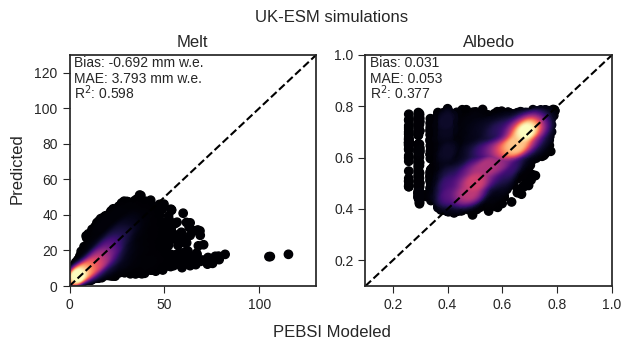

In [3]:
albedo_regression_vars = ['PDD_cumsum','bc_5d_rolling','days_since_acc','SWin']
model = joblib.load('../data/albedo_emulator.joblib')

df = pd.read_csv(base_fp + 'UKESM_all_snow_daily_df.csv')
f_SW = 1.3201e-6# 1.312e-6
f_T = 1.644 # 1.668

# get "baseline" prediction of melt
# df['SW_absorbed'] = df['SWin'] * (1 - df['albedo'])
# df['melt_base'] = df['SW_absorbed'] * f_SW + df['positive_temp'] * f_T

# remove low melt days 
df = df[df['melt'] > 2]

# get ML albedo and shortwave absorbed
df['albedo_ML'] = model.predict(df[albedo_regression_vars])
df['SW_absorbed_ML'] = df['SWin'] * (1 - df['albedo_ML'])

# calcualte melt from ML shortwave term
df['melt_ML'] = df['SW_absorbed_ML'] * f_SW + df['positive_temp'] * f_T

# plot
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes = axes.flatten()
for ax, var in zip(axes, ['melt','albedo']):
    # get x and y
    x = df[var].values 
    y = df[var + '_ML'].values

    # KDE analysis
    xy = np.vstack([x, y])
    z = kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]

    # get error metrics
    bias = np.nanmean(y - x)
    mae = np.nanmean(np.abs(y - x))
    r2 = 1 - np.sum(np.square(y - x)) / np.sum(np.square(x - np.mean(x)))

    # get min/max
    data_min = 0.1 if var == 'albedo' else 0 # np.min([x, y]) * 0.95
    data_max = 1 if var == 'albedo' else 130 # np.max([x, y]) * 1.05
    ax.set_xlim(data_min, data_max)
    ax.set_ylim(data_min, data_max)

    # plot
    ax.scatter(x, y, c=z, cmap='magma', label='Predictions')
    ax.plot([data_min, data_max],[data_min, data_max],'k--', label='1:1')

    unit = '' if var == 'albedo' else ' mm w.e.'
    ax.text(0.02, 0.95, f'Bias: {bias:.3f}'+unit, transform=ax.transAxes)
    ax.text(0.02, 0.88, f'MAE: {mae:.3f}'+unit, transform=ax.transAxes)
    ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)
    ax.set_title(var.capitalize())
    ax.tick_params(length=5)

fig.suptitle('UK-ESM simulations', y=1.03)
fig.supxlabel('PEBSI Modeled', y=-0.07)
fig.supylabel('Predicted', x=0.04)
plt.savefig('/trace/group/rounce/cvwilson/figs/ddf/ukesm_regression_results.png', dpi=300, bbox_inches='tight')
# plt.show()

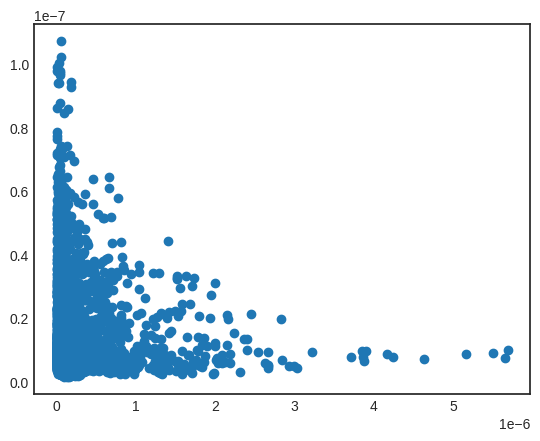

In [14]:
df_ukesm = pd.read_csv(base_fp + 'UKESM_all_snow_daily_df.csv', index_col=0, parse_dates=True)
df = pd.read_csv(base_fp + 'all_snow_daily_df.csv', index_col=0, parse_dates=True)
df = df.loc[df['glaciersite'] == 'gulkanaB']
df_ukesm = df_ukesm.loc[df_ukesm['glaciersite'] == 'gulkanaB']

common = np.intersect1d(df_ukesm.index, df.index)
df = df.loc[common]
df_ukesm = df_ukesm.loc[common]
plt.scatter(df.bc_5d_rolling, df_ukesm.bc_5d_rolling)
plt.show()

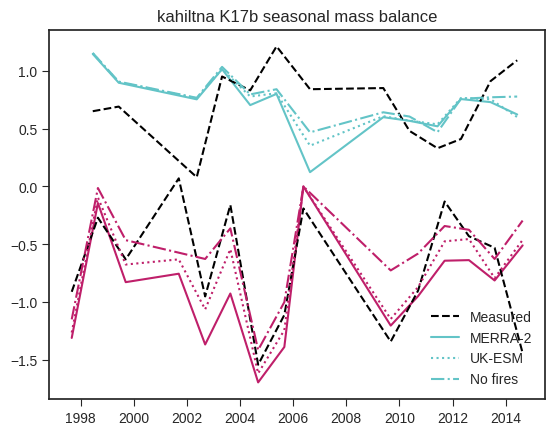

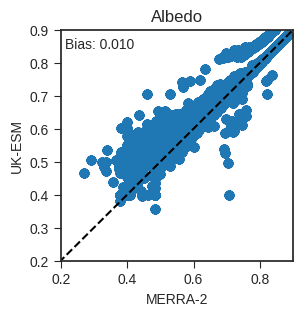

In [ ]:
glacier, site = 'kahiltna', 'K17b'

ds_merra2 = xr.open_dataset(base_fp + glacier+site+'_2026_04_06_merra2_0.nc')
ds_ukesm = xr.open_dataset(base_fp + glacier+site+'_2026_04_06_gfed_0.nc')
ds_nofires = xr.open_dataset(base_fp + glacier+site+'_2026_04_06_nofires_0.nc')

mb = MassBalance(glacier, site)
mb.get_model_mb(ds_merra2)
mod_merra2, meas = (mb.mod, mb.meas)
fig, ax = mb.plot_mb(mod_label='MERRA-2')

mb.get_model_mb(ds_ukesm)
mod_ukesm, meas = (mb.mod, mb.meas)
ends = mb.period_ends
if 'seasonal' in mb.dataset:
    idx_summer = mb.idx_summer 
    idx_winter = mb.idx_winter
    ax.plot(ends[idx_summer], mod_ukesm[idx_summer], color=colors[4], linestyle=':')
    ax.plot(ends[idx_winter], mod_ukesm[idx_winter], color=colors[0], linestyle=':', label='UK-ESM')
else:
    ax.plot(ends, mod_ukesm, color=colors[0], linestyle=':', label='UK-ESM')

mb.get_model_mb(ds_nofires)
mod_nofires, meas = (mb.mod, mb.meas)
if 'seasonal' in mb.dataset:
    idx_summer = mb.idx_summer 
    idx_winter = mb.idx_winter
    ax.plot(ends[idx_summer], mod_nofires[idx_summer], color=colors[4], linestyle='-.')
    ax.plot(ends[idx_winter], mod_nofires[idx_winter], color=colors[0], linestyle='-.', label='No fires')
else:
    ax.plot(ends, mod_nofires, color=colors[0], linestyle='-.', label='No fires')

ax.legend()
ax.tick_params(length=5)
plt.show()

albedo_merra2 = ds_merra2.albedo.values # .layerBC.isel(layer=0).values # 
albedo_ukesm = ds_ukesm.albedo.values
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(albedo_merra2, albedo_ukesm)
bias = np.nanmean(albedo_ukesm - albedo_merra2)
ax.text(0.02, 0.92, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.plot([0,1],[0,1],'k--',label='1:1')
ax.set_xlim(0.2,0.9)
ax.set_ylim(0.2,0.9)
ax.set_ylabel('UK-ESM')
ax.set_xlabel('MERRA-2')
ax.set_title('Albedo')
ax.tick_params(length=5)
plt.show()

In [ ]:
site_dict = {
    'kahiltna':['K17b','K53','K14k'], # KAHILTNA     'KPS',
    'kennicott':['KC31','GTL','GTH',], # KENNICOTT 
    'gulkana':['AU','B','D'], # GULKANA  
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C', 'D'], # LEMON CREEK
    'taku':['NWB1','MG1','TKG3'], # TAKU    
}

all_albedo = {'mod':[], 'meas':[], 'time':[]}
for glacier in ['gulkana']: # site_dict:
    for site in site_dict[glacier]:
        albedo = Albedo(glacier, site, use='all')
        ds = xr.open_dataset(base_fp + glacier + site +'_2026_03_19_long_0.nc')
        albedo.get_model_albedo(ds, months_range=list(range(4, 9)))
        # albedo.plot_timeseries()

        for mod, meas, date in zip(albedo.mod, albedo.meas, albedo.time):
            all_albedo['mod'].append(mod)
            all_albedo['meas'].append(meas)
            all_albedo['time'].append(date)

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)
markers = {'wolverine':'*', 'gulkana':'o', 'kahiltna':'3', 'kennicott':'^','lemon_creek':'.','taku':'1'}
# for glacier in site_dict:
#     for site in site_dict[glacier]:
#         albedo = Albedo(glacier, site)
#         ds = xr.open_dataset(base_fp + glacier + site +'_2026_03_04_base_3.nc')
#         albedo.get_model_albedo(ds)
#         ax.scatter(albedo.meas, albedo.mod, alpha=0.6, label=glacier, c=cmap(norm(pd.to_datetime(albedo.time).month)), marker=markers[glacier])
ax.scatter(all_albedo['meas'], all_albedo['mod'], alpha=0.6, label='Data', c=cmap(norm(pd.to_datetime(all_albedo['time']).month)))
ax.plot([0,1],[0,1],'k--',label='1:1')

bias = np.nanmean(np.array(all_albedo['mod']) - np.array(all_albedo['meas']))
mae = np.nanmean(np.abs(np.array(all_albedo['meas']) - np.array(all_albedo['mod'])))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)

ax.legend(frameon=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.tick_params(length=5)
ax.set_ylabel('Modeled albedo')
ax.set_xlabel('Measured albedo')
plt.show()

In [14]:
measurements = {'B':('2024-06-19', 5.102, 65.19),
                'D':('2024-08-21', 10.51, 262.45)}

for site in measurements:
    ds = xr.open_dataset(base_fp + f'gulkana{site}_2026_03_19_long_0.nc')
    
    # dsc = ds.sel(time=slice(pd.to_datetime(measurements[site][0]) - pd.Timedelta(days=1), pd.to_datetime(measurements[site][0]) + pd.Timedelta(days=1)))
    # plt.plot(dsc.time, dsc.layerBC.isel(layer=range(3)).mean(dim='layer'))
    # plt.show()
    date = measurements[site][0]
    modeled_bc = ds.sel(time=pd.to_datetime(date)).layerBC.isel(layer=range(1)).mean()
    modeled_dust = ds.sel(time=pd.to_datetime(date)).layerdust.isel(layer=range(1)).mean()
    print(f'Gulkana {site} on {date}')
    print('   Measured BC:', measurements[site][1],'ppb')
    print(f'   Modeled BC: {modeled_bc:.2f} ppb')
    print('   Measured dust:', measurements[site][2],'ppm')
    print(f'   Modeled dust: {modeled_dust:.2f} ppm')

Gulkana B on 2024-06-19
   Measured BC: 5.102 ppb
   Modeled BC: 101.40 ppb
   Measured dust: 65.19 ppm
   Modeled dust: 1.70 ppm
Gulkana D on 2024-08-21
   Measured BC: 10.51 ppb
   Modeled BC: 19.55 ppb
   Measured dust: 262.45 ppm
   Modeled dust: 0.17 ppm


In [ ]:
bc_fp = '/trace/group/rounce/cvwilson/Output/bc_dust/'
dust_factors = [20, 50, 75, 100]
ksp_BCs = [0.1, 0.5, 0.9, 1]
all_error_BC = np.zeros((len(dust_factors), len(ksp_BCs)))
all_error_dust = np.zeros((len(dust_factors), len(ksp_BCs)))

for site in ['Taku-1','Mend-2', 'Mend-3', 'Lemon-1']:
    out_bc = np.zeros((len(dust_factors), len(ksp_BCs)))
    out_dust = np.zeros((len(dust_factors), len(ksp_BCs)))
    for i, dust_factor in enumerate(dust_factors):
        for j, ksp_BC in enumerate(ksp_BCs):
            ds = xr.open_dataset(bc_fp + f'grid_{site}_{dust_factor}_{ksp_BC}_0.nc')
            time = pd.date_range('2016-07-18 00:00', '2016-07-18 23:00', freq='h')
            bc_final = ds.sel(time=time).layerBC.isel(layer=range(2)).mean(dim=['layer','time'])
            dust_final = ds.sel(time=time).layerdust.isel(layer=range(2)).mean(dim=['time','layer'])
            out_bc[i, j] = bc_final
            out_dust[i, j] = dust_final 
    
    lap = LAPs(site)
    error_bc = (out_bc - lap.bc_july) / lap.bc_july #0
    error_dust = (out_dust - lap.dust_july) / lap.dust_july

    all_error_BC += error_bc 
    all_error_dust += error_dust

idx_bc = np.argmin(np.abs(all_error_BC)) #  + error_dust))
i, j = np.unravel_index(idx_bc, error_bc.shape)
best_dust = dust_factors[i]
best_ksp = ksp_BCs[j]

print(f"On BC: site: {site} | Best Dust: {best_dust} | Best ksp_BC: {best_ksp} | Error: BC {all_error_BC[i, j]}, Dust {all_error_dust[i, j]}")

idx_bc = np.argmin(np.abs(all_error_dust)) #  + error_dust))
i, j = np.unravel_index(idx_bc, error_bc.shape)
best_dust = dust_factors[i]
best_ksp = ksp_BCs[j]

print(f"On dust: site: {site} | Best Dust: {best_dust} | Best ksp_BC: {best_ksp} | Error: BC {all_error_BC[i, j]}, Dust {all_error_dust[i, j]}")

idx_bc = np.argmin(np.abs(all_error_BC + all_error_dust)) #  + error_dust))
i, j = np.unravel_index(idx_bc, error_bc.shape)
best_dust = dust_factors[i]
best_ksp = ksp_BCs[j]

print(f"On both: site: {site} | Best Dust: {best_dust} | Best ksp_BC: {best_ksp} | Error: BC {all_error_BC[i, j]}, Dust {all_error_dust[i, j]}")

Optimal Parameters: Dust Factor: 20, ksp_BC: 1


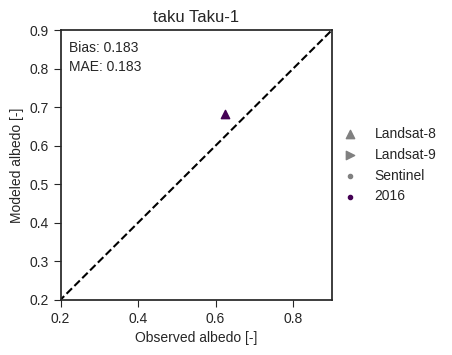

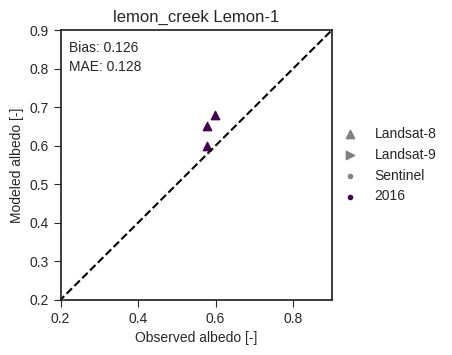

In [4]:
for glacier, site in zip(['taku','lemon_creek'], ['Taku-1','Lemon-1']): 
    ds = xr.open_dataset(bc_fp + f'grid_{site}_75_1_0.nc')
    albedo = Albedo(glacier, site, use='all')
    albedo.get_model_albedo(ds)
    albedo.plot_1to1()

In [ ]:
from contextlib import redirect_stdout
import os
from project.data_handling import Albedo 

glacier, site = 'lemon_creek','D'
rs = Albedo(glacier, site, use='all')
idx = np.argmin(np.abs(pd.to_datetime(rs.time) - pd.to_datetime('2016-07-18')))
print(rs.time[idx], rs.data[idx])

# rs.plot_map(plot_sites=['D','Lemon-1']) # 'MG1','TKG3','NWB1','Taku-1'])
ds_good = xr.open_dataset(f'/trace/group/rounce/cvwilson/Output/ddf/{glacier}{site}_2026_04_30_dust50x_0.nc')
print(ds_good.sel(time=pd.to_datetime(rs.time[idx])).albedo.values)

print(ds_good.sel(time=pd.to_datetime('2016-07-18 14:00'), layer=0).layerBC.values)
print(ds_good.sel(time=pd.to_datetime('2016-07-18 14:00'), layer=0).layerdust.values)